In [145]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import itertools
from torch.autograd import Variable
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split

# ============================
# FIX RANDOMNESS HERE
# ============================
seed = 42
np.random.seed(seed)          
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ============================

In [146]:
# ------------------------------------------------------
# 1. Fuzzy C-Means for Initialization (Skfuzzy Required)
# ------------------------------------------------------

def fcm_initialize(X, K):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    """
    X_t = X.T  # (features=4, samples=N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=2.0,
        error=1e-5,
        maxiter=2000,
    )

    N = X.shape[0]
    n_inputs = X.shape[1]

    spreads = []
    for k in range(K):
        weights = u[k]                    # (N,)
        w = weights.reshape(N, 1)         # (N,1)

        diff = X - cntr[k]                # (N,4)
        var = np.sum(w * diff**2, axis=0) / np.sum(w)
        spreads.append(np.sqrt(var) + 1e-5)

    return np.array(cntr), np.array(spreads)


# ------------------------------------------------------
# 2. Prepare Mackey-Glass Dataset
# ------------------------------------------------------

beta = 0.2
tau = 17
gamma = 0.1
n = 10
dt = 0.1

delay = int(tau / dt)
init_value = 1.2
T = 1000
num_steps = int(T/dt)

x = np.zeros(num_steps)
x[:delay] = init_value
time = np.arange(num_steps) * dt

for t in range(delay, num_steps-1):
    feedback = (beta * x[t-delay]) / (1 + (x[t-delay])**n)
    x[t+1] = x[t] + dt * (feedback - gamma*x[t])

time_pos = time[delay:]
x_pos = x[delay:]

lags = [24, 18, 12, 6]
X, y = [], []

for t in range(max(lags), len(x_pos)):
    X.append([x_pos[t - lag] for lag in lags])
    y.append(x_pos[t])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

# ------------------------------------------------------
# 3. Train/Test Split
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)
X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)


n_inputs = 4
K = 9

# ------------------------------------------------------
# 4. FCM Initialization
# ------------------------------------------------------
centers_init, spreads_init = fcm_initialize(X_train, K)

In [147]:
# ------------------------------------------------------
# 4. Gaussian MF Layer
# ------------------------------------------------------

class GaussianMF_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))

    def forward(self, x):
        # x shape: (batch, n_inputs)
        x_exp = x.unsqueeze(1)  # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)  # (1, K, n_inputs)
        s_exp = self.spreads.unsqueeze(0)  # (1, K, n_inputs)

        mu = torch.exp(-((x_exp - c_exp)**2) / (2 * s_exp**2))  # (batch, K, n_inputs)

        # AND across inputs
        firing = torch.prod(mu, dim=2)  # (batch, K)
        return firing
        

# ------------------------------------------------------
# 5. ANFIS Model With FCM Initialization
# ------------------------------------------------------

class ANFIS_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()

        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.mf_layer = GaussianMF_FCM(centers_init, spreads_init)

        # One linear function per rule
        self.consequents = nn.Parameter(torch.randn(self.K, self.n_inputs + 1))


    def forward(self, x):
        w = self.mf_layer(x)  # (batch, K)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)

        # linear outputs
        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)
        y_r = torch.sum(x_exp * self.consequents[:, :-1], dim=2) + self.consequents[:, -1]

        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)
        return y_pred

In [148]:
# ------------------------------------------------------
# 6. Train With Adam
# ------------------------------------------------------

model = ANFIS_FCM(centers_init, spreads_init)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(1500):
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)
    loss = loss_fn(y_pred_train, y_train_tensor)
    loss.backward()
    optimizer.step()

# numpy prediction
y_pred_np = y_pred.detach().numpy()


Test MSE adam + fcm init:  0.00034520176
Root MSE:  0.020368889


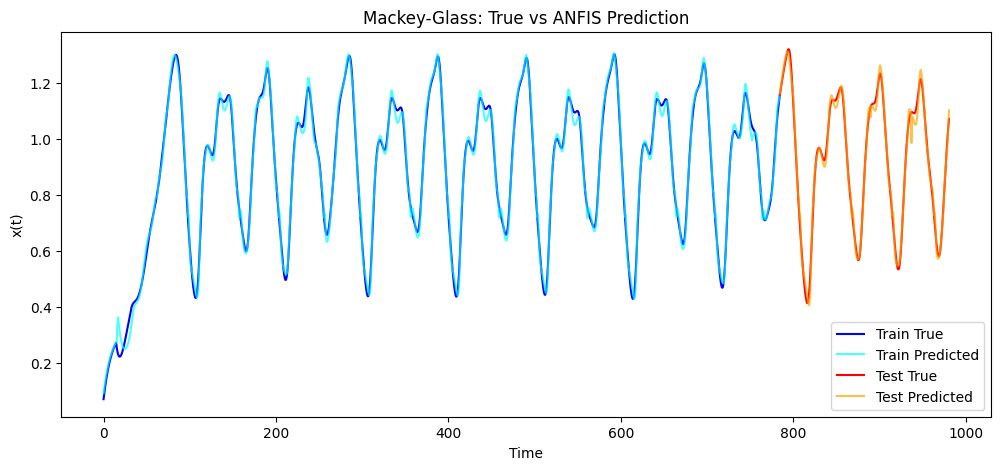

In [151]:
y_pred_test_np = model(X_test_tensor).detach().numpy()

test_mse = np.mean((y_test - y_pred_test_np)**2)
test_rmse = test_mse ** (1/2)

print("Test MSE adam + fcm init: ", mse_cost)
print("Root MSE: ", test_rmse)

# Create a time array
dt = 0.1  # your timestep
time_pred = np.arange(len(y_true_np)) * dt

# Plot full series
plt.figure(figsize=(12, 5))
plt.plot(time_train, y_train, label="Train True", color="blue")
plt.plot(time_train, y_pred_train_np, label="Train Predicted", color="cyan", alpha=0.7)
plt.plot(time_test, y_test, label="Test True", color="red")
plt.plot(time_test, y_pred_test_np, label="Test Predicted", color="orange", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Mackey-Glass: True vs ANFIS Prediction")
plt.legend()
plt.show()